# Chronos2 Variable-Length Inference (Batch vs Individual)

This concise example compares batched and individual inference for variable-length inputs using `Chronos2Model`.

In [8]:
import numpy as np

import datasets
from darts.datasets import AirPassengersDataset
from darts.models import Chronos2Model

datasets.disable_progress_bars()

N = 5  # forecast horizon
ATOL = 2e-5

In [9]:
data = AirPassengersDataset().load().astype(np.float32)

# Variable-length inference inputs (different history lengths).
series_list = [
    data[0:24],
    data[5:20],
    data[10:18],
    data[18:30],
]

MAX_INPUT_LENGTH = max(len(s) for s in series_list)

# Bootstrap fit series to initialize the model (fine-tuning disabled by default).
bootstrap_series = data[:60]

print("Input lengths:", [len(s) for s in series_list])
print("MAX_INPUT_LENGTH:", MAX_INPUT_LENGTH)

Input lengths: [24, 15, 8, 12]
MAX_INPUT_LENGTH: 24


In [10]:
def compare_batch_vs_individual(model, series, n, atol=1e-6):
    pred_batch = model.predict(n=n, series=series)
    pred_individual = [model.predict(n=n, series=s) for s in series]

    max_abs_diffs = []
    is_close = []
    for pb, pi in zip(pred_batch, pred_individual):
        vb = pb.all_values(copy=False)
        vi = pi.all_values(copy=False)
        diff = np.max(np.abs(vb - vi))
        max_abs_diffs.append(float(diff))
        is_close.append(bool(np.allclose(vb, vi, atol=atol, rtol=0.0)))

    return max_abs_diffs, is_close

In [11]:
chronos = Chronos2Model(
    input_chunk_length=MAX_INPUT_LENGTH,
    output_chunk_length=2,
    hub_model_name="autogluon/chronos-2-small",
)
chronos.fit(series=bootstrap_series, verbose=False)

chronos_diffs, chronos_equal = compare_batch_vs_individual(
    chronos, series_list, n=N, atol=ATOL
)

{
    "model": "Chronos2Model",
    "allclose": all(chronos_equal),
    "allclose_per_series": chronos_equal,
    "max_diff": max(chronos_diffs),
}

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
c:\projects\darts\.venv\Lib\site-packages\pytorch_lightning\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
c:\projects\darts\.venv\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Predicting DataLoader 0: 100%|██████████| 1/1 [00:00<00:00, 31.83it/s]

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs



Predicting DataLoader 0: 100%|██████████| 1/1 [00:00<00:00, 42.93it/s]

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


...

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs



Predicting DataLoader 0: 100%|██████████| 1/1 [00:00<00:00, 59.84it/s]

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs



Predicting DataLoader 0: 100%|██████████| 1/1 [00:00<00:00, 29.36it/s]


{'model': 'Chronos2Model',
 'allclose': True,
 'allclose_per_series': [True, True, True, True],
 'max_diff': 1.52587890625e-05}

In [12]:
print(
    f"Chronos2Model: allclose={all(chronos_equal)}, "
    f"max_diff={max(chronos_diffs):.8f}, "
    f"per_series={chronos_equal}"
)

Chronos2Model: allclose=True, max_diff=0.00001526, per_series=[True, True, True, True]


In [13]:
summary = {
    "Chronos2Model": {
        "allclose": all(chronos_equal),
        "max_diff": max(chronos_diffs),
        "allclose_per_series": chronos_equal,
    }
}
summary

{'Chronos2Model': {'allclose': True,
  'max_diff': 1.52587890625e-05,
  'allclose_per_series': [True, True, True, True]}}

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Predicting: |          | 0/? [00:00<?, ?it/s]

Predicting DataLoader 0: 100%|██████████| 1/1 [00:00<00:00, 31.71it/s]

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs



Predicting DataLoader 0: 100%|██████████| 1/1 [00:00<00:00, 46.61it/s]

...


Predicting DataLoader 0: 100%|██████████| 1/1 [00:00<00:00, 41.93it/s]

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs



Predicting DataLoader 0: 100%|██████████| 1/1 [00:00<00:00, 57.08it/s]

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs



Predicting DataLoader 0: 100%|██████████| 1/1 [00:00<00:00, 55.32it/s]


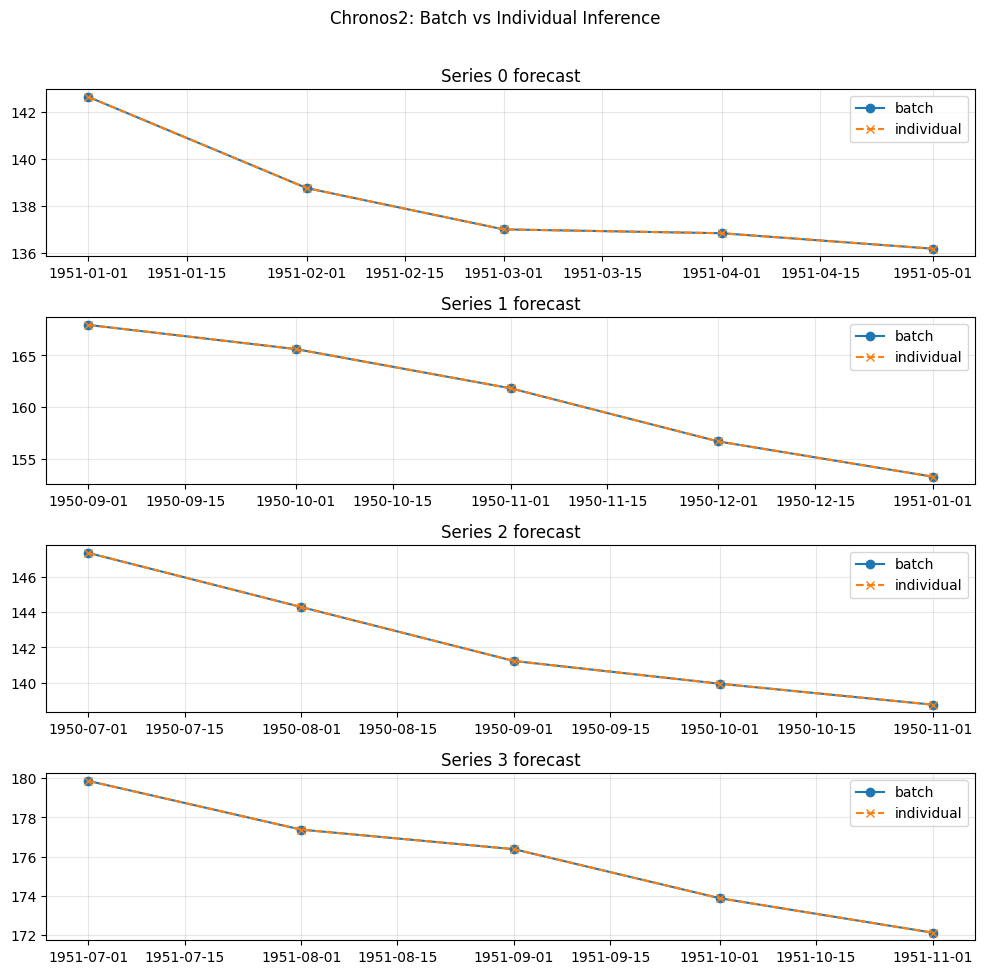

In [15]:
import matplotlib.pyplot as plt

pred_batch = chronos.predict(n=N, series=series_list)
pred_individual = [chronos.predict(n=N, series=s) for s in series_list]

n_rows = len(series_list)
fig, axes = plt.subplots(n_rows, 1, figsize=(10, 2.4 * n_rows), squeeze=False)

for i, (pb, pi) in enumerate(zip(pred_batch, pred_individual)):
    # Left: overlaid predictions
    ax = axes[i, 0]
    ax.plot(pb.time_index, pb.univariate_values(), marker="o", label="batch")
    ax.plot(
        pi.time_index,
        pi.univariate_values(),
        marker="x",
        linestyle="--",
        label="individual",
    )
    ax.set_title(f"Series {i} forecast")
    ax.grid(alpha=0.3)
    ax.legend(loc="best")


fig.suptitle("Chronos2: Batch vs Individual Inference", y=1.01)
fig.tight_layout()
plt.show()

Interpretation:

- `allclose=True` means batched and individual Chronos2 predictions are numerically comparable at `ATOL`.
- `max_diff` reports the largest absolute difference across all compared outputs.